In [1]:
import pandas as pd

# Load one of the prepared tickers
df = pd.read_parquet("data/prepared/SPY_with_features.parquet")

# Inspect the structure
df.tail(10)


Price,Close,excess_12m_return,signal_12m_return
Date,,,
2025-06-16,600.903564,-0.093829,-1
2025-06-17,595.768799,-0.105710,-1
2025-06-18,595.679016,-0.106556,-1
2025-06-20,594.280029,-0.117955,-1
2025-06-23,600.150024,-0.109881,-1
2025-06-24,606.780029,-0.094542,-1
2025-06-25,607.119995,-0.092398,-1
2025-06-26,611.869995,-0.079855,-1
2025-06-27,614.909973,-0.078585,-1


In [2]:
# Calculate daily returns
df["daily_return"] = df["Close"].pct_change()

# Shift the signal to avoid lookahead bias (you act on yesterday’s signal)
df["shifted_signal"] = df["signal_12m_return"].shift(1)

# Strategy return = shifted signal * daily return
df["strategy_return"] = df["shifted_signal"] * df["daily_return"]

# Drop NaNs
df.dropna(inplace=True)

# Show last 5 rows
df.tail()


Price,Close,excess_12m_return,signal_12m_return,daily_return,shifted_signal,strategy_return
Date,,,,,,
2025-06-24,606.780029,-0.094542,-1,0.011047,-1.0,-0.011047
2025-06-25,607.119995,-0.092398,-1,0.000560,-1.0,-0.000560
2025-06-26,611.869995,-0.079855,-1,0.007824,-1.0,-0.007824
2025-06-27,614.909973,-0.078585,-1,0.004968,-1.0,-0.004968
2025-06-30,617.849976,-0.074552,-1,0.004781,-1.0,-0.004781


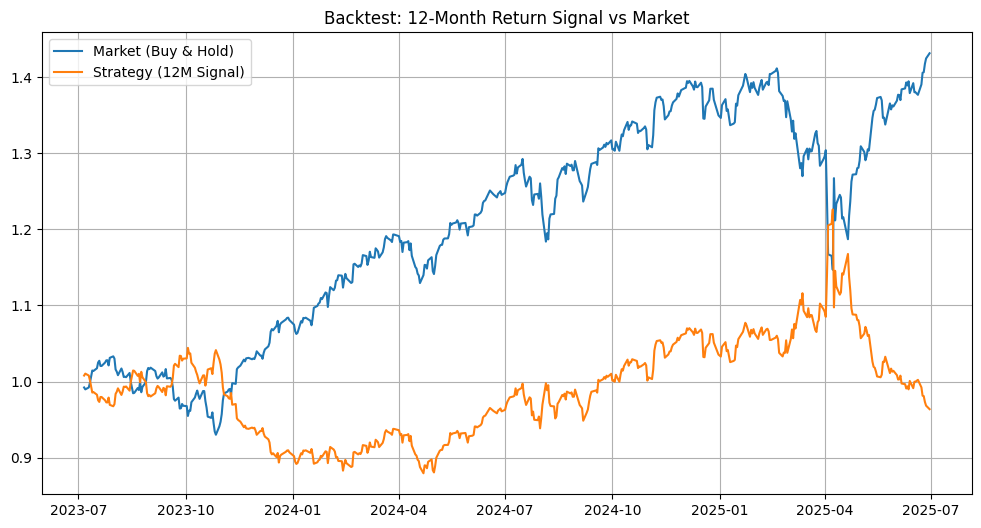

In [3]:
import matplotlib.pyplot as plt

df["cumulative_market_return"] = (1 + df["daily_return"]).cumprod()
df["cumulative_strategy_return"] = (1 + df["strategy_return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["cumulative_market_return"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_strategy_return"], label="Strategy (12M Signal)")
plt.title("Backtest: 12-Month Return Signal vs Market")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# Compute metrics
total_return = df["cumulative_strategy_return"].iloc[-1] - 1
volatility = df["strategy_return"].std() * (252**0.5)
sharpe = df["strategy_return"].mean() / df["strategy_return"].std() * (252**0.5)

print(f"Total Strategy Return: {total_return:.2%}")
print(f"Annualized Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")


Total Strategy Return: -3.64%
Annualized Volatility: 16.59%
Sharpe Ratio: -0.03
